In [19]:
import json
import os

import cv2
import matplotlib.pyplot as plt

from src.gait_analysis.data_cleaning.data_smoothing import smooth_pose_data
from src.utils.visualization.plot_keypoint_positions import plot_kinematic_chain
from src.utils.parse_annotations.manual import parse_annotations
from src.utils.overlay.drawing import draw_runner_skeleton

In [20]:
model_id = "000332"
video_key = "v2"  # v1 or v2
setting = "outdoor"  # "treadmill" or "outdoor"
fps = 240
if fps == 240:
    fps_name = "RES1080_FPS240_LENwide"
elif fps == 60:
    fps_name = "RES1080_FPS60_LENlinear"
else:
    quit()
#fps = "RES1080_FPS240_LENwide"  # "RES1080_FPS240_LENwide" or "RES1080_FPS60_LENlinear"

annotations_path = f"../data/output/annotations/{setting}/{fps_name}/{video_key}_overlay.csv"
video_path = f"../data/input/high_fps/{setting}/{fps_name}/{video_key}.mp4"
pose_model_output_path = f"../data/output/tuned_yolo/{model_id}/{setting}/{fps_name}/{video_key}.json"
cap = cv2.VideoCapture(video_path)
FPS = cap.get(cv2.CAP_PROP_FPS)

cap.get(cv2.CAP_PROP_FRAME_WIDTH), cap.get(cv2.CAP_PROP_FRAME_HEIGHT), cap.get(cv2.CAP_PROP_FRAME_COUNT)
cap.release()
with open(os.path.join(pose_model_output_path), "r") as f:
    pose_model_output = json.load(f)

connections = pose_model_output["connections"]
pose_data = pose_model_output["pose_data"]

anchors = ["heel", "big_toe", "knee"]
keypoints = list(set([x for xs in connections for x in xs]))
keys_to_exclude = {"raw_keypoints"}

smooth_data = smooth_pose_data(
    pose_data=pose_data,
    keypoints=keypoints,
    anchors=anchors,
    keys_to_exclude=keys_to_exclude,
    fps=FPS,
    cutoff=4.0,
)

smooth_data['frame'] = (smooth_data['timestamp_ms'] / 1000 * fps).astype(int)
smooth_data = smooth_data.set_index('frame')

In [21]:
def get_overlay_for_frame(video_path, pose_data, frame_index, skeleton_connections):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame = cap.read()

    if not success:
        print(f"Error: Could not read frame {frame_index} from {video_path}")
        cap.release()
        return None

    if frame_index < len(pose_data):
        frame_data = pose_data[frame_index]

        if frame_data is not None:
            try:
                draw_runner_skeleton(frame, frame_data, skeleton_connections)
            except Exception as e:
                print(f"Error drawing skeleton on frame {frame_index}: {e}")
    else:
        print(f"Error: Frame index {frame_index} out of bounds for pose_data.")

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    cap.release()
    return frame_rgb

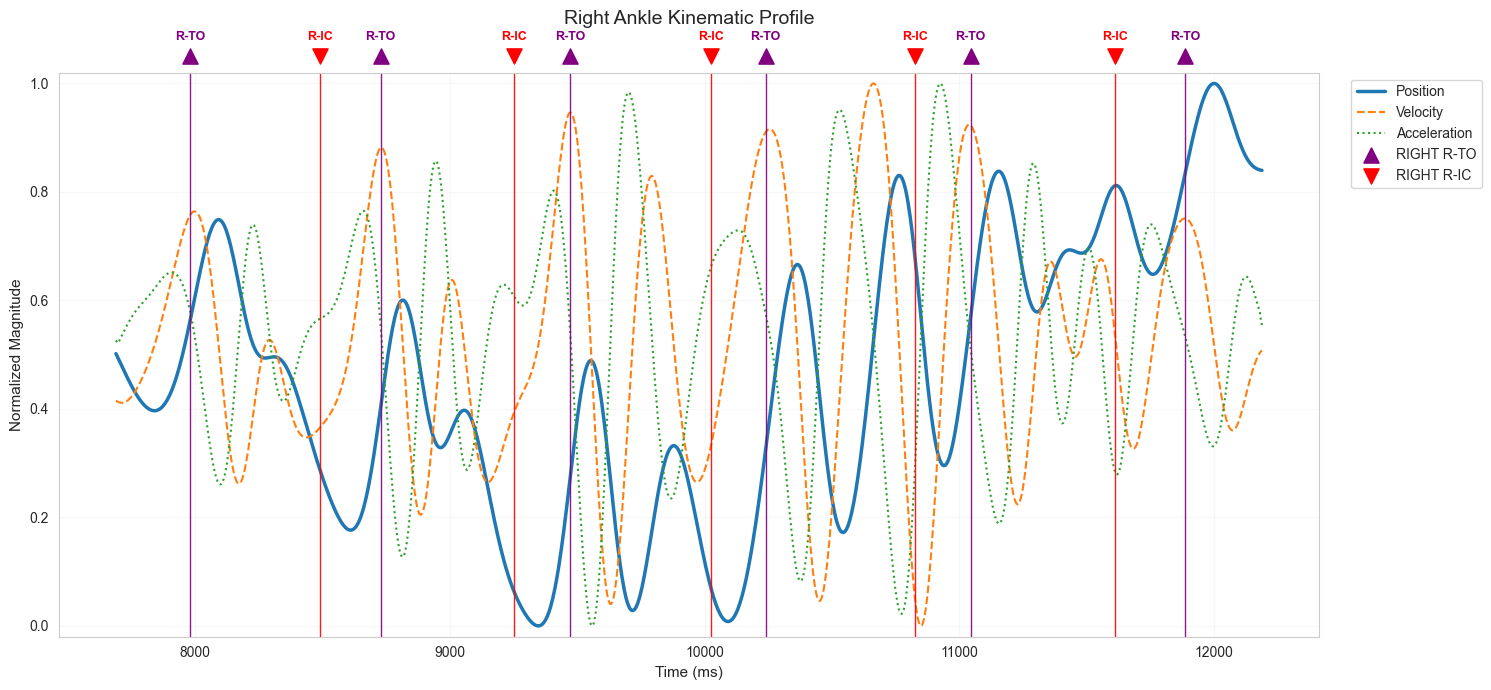

In [22]:
ann_df = parse_annotations(annotations_path)
plot_kinematic_chain(smooth_data, ann_df, "right", "ankle", "y", fps)

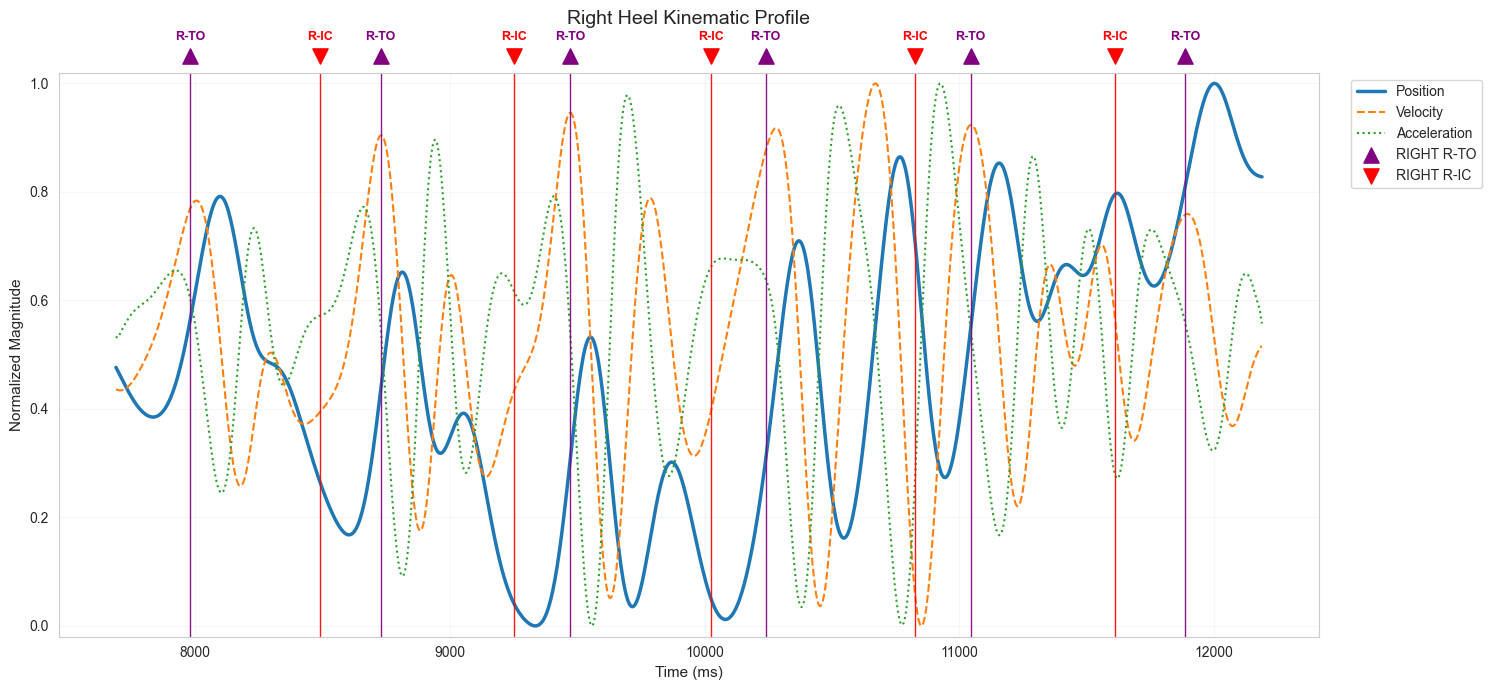

In [23]:
ann_df = parse_annotations(annotations_path)
plot_kinematic_chain(smooth_data, ann_df, "right", "heel", "y", fps)

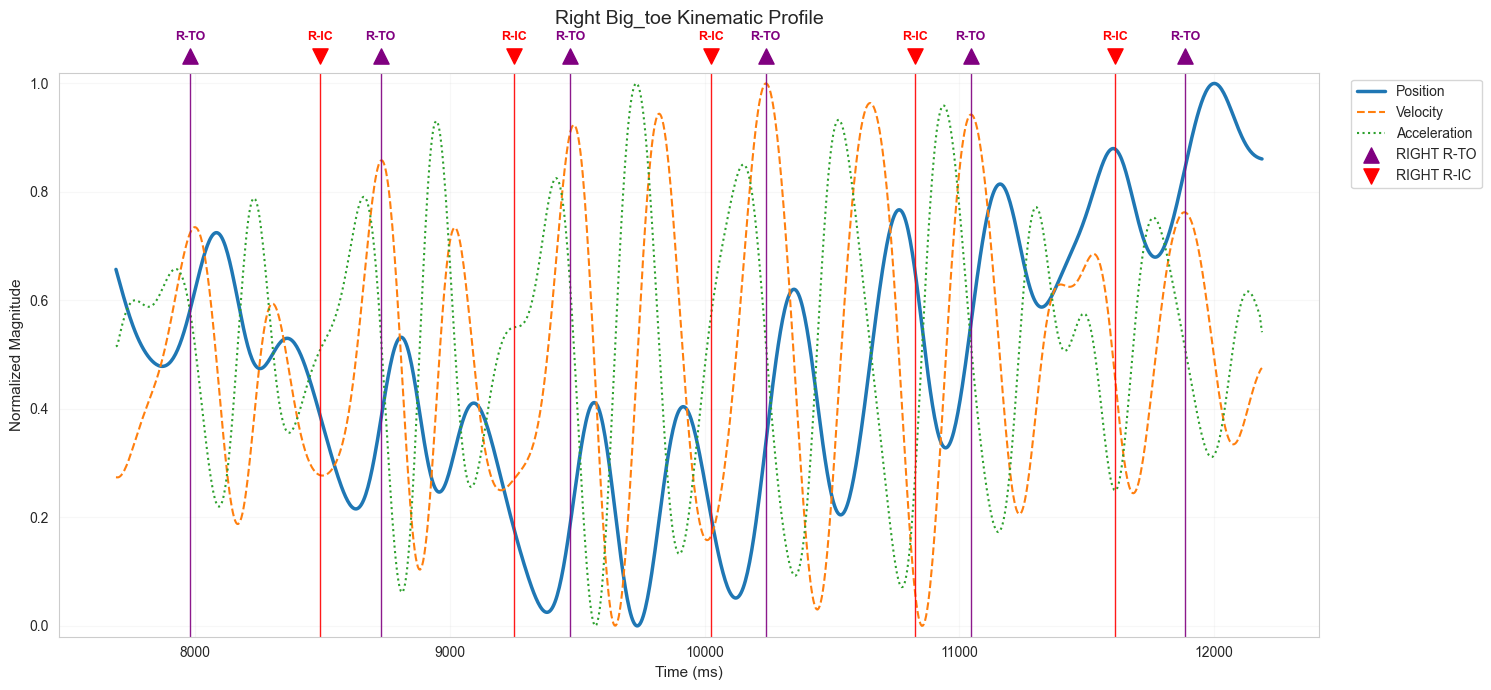

In [24]:
plot_kinematic_chain(smooth_data, ann_df, "right", "big_toe", "y", fps)

In [25]:
ann_df[ann_df['side'] == 'right']

,frame,event_id,label,side,event_type
1915,1915,4,RIGHT Liftoff (R-TO),right,R-TO
2038,2038,2,RIGHT Initial Contact (R-IC),right,R-IC
2095,2095,4,RIGHT Liftoff (R-TO),right,R-TO
2220,2220,2,RIGHT Initial Contact (R-IC),right,R-IC
2273,2273,4,RIGHT Liftoff (R-TO),right,R-TO
2406,2406,2,RIGHT Initial Contact (R-IC),right,R-IC
2457,2457,4,RIGHT Liftoff (R-TO),right,R-TO
2598,2598,2,RIGHT Initial Contact (R-IC),right,R-IC
2650,2650,4,RIGHT Liftoff (R-TO),right,R-TO
2786,2786,2,RIGHT Initial Contact (R-IC),right,R-IC


In [26]:
smooth_data.loc[1915]

timestamp_ms             7982.975000
track_id                    1.000000
bbox_area               13304.616211
bbox_x1                    75.880608
bbox_y1                   611.625977
bbox_w                     77.694153
bbox_h                    171.243469
left_shoulder_x            93.506574
left_shoulder_y           559.009132
left_shoulder_conf          0.856620
right_shoulder_x           77.810014
right_shoulder_y          558.294332
right_shoulder_conf         0.869783
left_hip_x                 87.276364
left_hip_y                607.365840
left_hip_conf               0.877449
right_hip_x                72.010708
right_hip_y               608.141183
right_hip_conf              0.885309
left_knee_x               104.649604
left_knee_y               637.866313
left_knee_conf              0.882426
right_knee_x               61.458502
right_knee_y              641.974137
right_knee_conf             0.887682
left_ankle_x               96.548375
left_ankle_y              674.871756
l

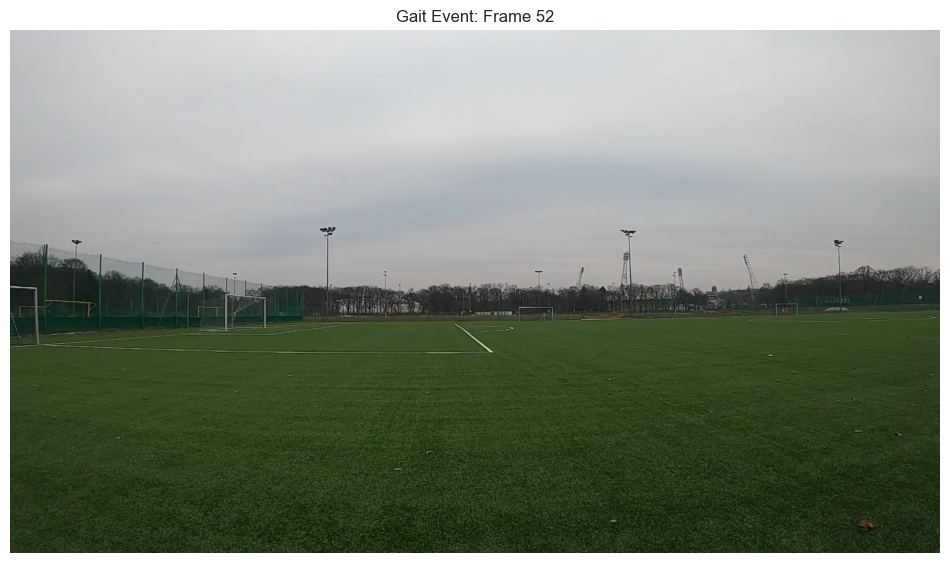

In [27]:
target_frame = 52
frame_rgb = get_overlay_for_frame(video_path, pose_data, target_frame, pose_model_output['connections'])
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title(f"Gait Event: Frame {target_frame}")
plt.axis('off')
plt.show()